# Predicting and Explaining Traffic Collision Severity in Toronto
## Using Explainable Machine Learning

**Author:** Nishi Bhavesh Patel | Student ID: 501356244  
**Program:** Master of Data Science & Analytics (Full-Time)  
**Date:** April 2026


---
### Sections
1. Install & Import Libraries
2. Load & Fix Collision Data
3. Download & Clean Weather Data
4. Merge Datasets
5. Data Cleaning & Target Variable
6. Feature Engineering
7. Exploratory Data Analysis (EDA)
8. Prepare Data for Modeling
9. Model Training
10. Model Evaluation
11. SHAP Explainability
12. Geospatial Hotspot Mapping
13. Subgroup Analysis
14. Final Summary

---
## Section 1 — Install & Import Libraries

In [ ]:
# Uncomment and run once if packages not installed
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap folium imbalanced-learn plotly pytz


In [1]:
import numpy as np
import pandas as pd
import warnings
import os
import time
import requests
from io import StringIO
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.cluster import DBSCAN
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42
severity_labels = {0: 'Minor', 1: 'Major', 2: 'Fatal'}

print('All libraries loaded!')

All libraries loaded!


---
## Section 2 — Load & Fix Collision Data

Download from: https://open.toronto.ca/dataset/motor-vehicle-collisions-involving-killed-or-seriously-injured-persons/

In [2]:
# ── STEP 1: Load raw CSV ──
COLLISION_FILE = '../MRP - Final Sem/Data/toronto_collisions.csv'

collisions = pd.read_csv(COLLISION_FILE, low_memory=False)
print(f'Raw shape: {collisions.shape}')
collisions.head(3)

Raw shape: (809034, 21)


,_id,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,FTR_COLLISIONS,...,HOOD_158,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,geometry
0,1,1.388550e+12,January,Wednesday,2014,1,D52,NaN,NO,NO,...,168,Downtown Yonge East (168),-79.378428,43.65041,YES,NO,NO,NO,NO,"{""coordinates"": [[-79.378427745, 43.65041009]]..."
1,2,1.388550e+12,January,Wednesday,2014,22,D32,NaN,YES,NO,...,NSA,NSA,0.000000,0.00000,YES,NO,NO,NO,NO,"{""coordinates"": [[5.6843418860808e-14, 5.08888..."
2,3,1.388550e+12,January,Wednesday,2014,2,NSA,NaN,YES,NO,...,NSA,NSA,0.000000,0.00000,YES,NO,NO,NO,NO,"{""coordinates"": [[5.6843418860808e-14, 5.08888..."


In [3]:
# ── STEP 2: Remove duplicate rows using _id ──
before = len(collisions)
collisions = collisions.drop_duplicates(subset=['_id'])
print(f'Removed {before - len(collisions):,} duplicate rows')
print(f'Remaining: {len(collisions):,} rows')

Removed 0 duplicate rows
Remaining: 809,034 rows


In [4]:
# ── STEP 3: Fix OCC_DATE (Unix timestamp in milliseconds → Toronto datetime) ──
collisions['datetime'] = pd.to_datetime(
    collisions['OCC_DATE'], unit='ms', errors='coerce'
)

# Convert from UTC to Toronto local time
collisions['datetime'] = (
    collisions['datetime']
    .dt.tz_localize('UTC')
    .dt.tz_convert('America/Toronto')
    .dt.tz_localize(None)
    .dt.floor('H')
)

collisions = collisions.dropna(subset=['datetime'])
print(f'Date range: {collisions["datetime"].min()} to {collisions["datetime"].max()}')
print(f'Records: {len(collisions):,}')

Date range: 2013-12-31 23:00:00 to 2026-03-31 00:00:00
Records: 809,034


In [5]:
# ── STEP 4: Re-derive all time columns from datetime (reliable source of truth) ──
collisions['OCC_YEAR']  = collisions['datetime'].dt.year
collisions['OCC_MONTH'] = collisions['datetime'].dt.month
collisions['OCC_HOUR']  = collisions['datetime'].dt.hour
collisions['OCC_DOW']   = collisions['datetime'].dt.day_name()

print('Time columns fixed from datetime:')
print(f'  Year range:  {collisions["OCC_YEAR"].min()} to {collisions["OCC_YEAR"].max()}')
print(f'  Month range: {collisions["OCC_MONTH"].min()} to {collisions["OCC_MONTH"].max()}')
print(f'  Hour range:  {collisions["OCC_HOUR"].min()} to {collisions["OCC_HOUR"].max()}')
print(f'  Days:        {sorted(collisions["OCC_DOW"].unique())}')

Time columns fixed from datetime:
  Year range:  2013 to 2026
  Month range: 1 to 12
  Hour range:  0 to 23
  Days:        ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']


In [6]:
# ── STEP 5: Fix GPS — replace 0.0 coordinates with NaN ──
collisions['LAT_WGS84']  = collisions['LAT_WGS84'].replace(0.0, np.nan)
collisions['LONG_WGS84'] = collisions['LONG_WGS84'].replace(0.0, np.nan)

print(f'Valid GPS:   {collisions["LAT_WGS84"].notna().sum():,}')
print(f'Invalid GPS: {collisions["LAT_WGS84"].isna().sum():,} (will be dropped later)')

Valid GPS:   677,056
Invalid GPS: 131,978 (will be dropped later)


In [7]:
# ── STEP 6: Final overview ──
print('='*55)
print('  COLLISION DATA — FINAL OVERVIEW')
print('='*55)
print(f'  Rows:     {len(collisions):,}')
print(f'  Columns:  {collisions.shape[1]}')
print(f'\n  Date range:')
print(f'    From: {collisions["datetime"].min()}')
print(f'    To:   {collisions["datetime"].max()}')
print(f'\n  Records per year:')
print(collisions['OCC_YEAR'].value_counts().sort_index().to_string())
print(f'\n  GPS valid:   {collisions["LAT_WGS84"].notna().sum():,}')
print(f'  GPS invalid: {collisions["LAT_WGS84"].isna().sum():,}')
print(f'\n  Fatalities > 0:  {(collisions["FATALITIES"] > 0).sum():,}')
print(f'  Injury = YES:    {(collisions["INJURY_COLLISIONS"] == "YES").sum():,}')
print(f'  Minor (rest):    {((collisions["FATALITIES"].fillna(0) == 0) & (collisions["INJURY_COLLISIONS"] != "YES")).sum():,}')
print(f'\n  Months:')
print(collisions['OCC_MONTH'].value_counts().sort_index().to_string())
print('='*55)

  COLLISION DATA — FINAL OVERVIEW
  Rows:     809,034
  Columns:  22

  Date range:
    From: 2013-12-31 23:00:00
    To:   2026-03-31 00:00:00

  Records per year:
OCC_YEAR
2013       73
2014    64523
2015    67371
2016    69563
2017    74507
2018    78973
2019    82962
2020    44608
2021    43838
2022    59080
2023    67542
2024    70181
2025    67659
2026    18154

  GPS valid:   677,056
  GPS invalid: 131,978

  Fatalities > 0:  666
  Injury = YES:    109,715
  Minor (rest):    698,656

  Months:
OCC_MONTH
1     74348
2     70986
3     66286
4     55888
5     64693
6     66367
7     66043
8     64844
9     68385
10    70769
11    70249
12    70176


---
## Section 3 — Download & Clean Weather Data

**Station:** TORONTO CITY (ID: 31688) — automatic station, complete hourly records 2002–2026.

In [8]:
STATION_ID   = 31688
WEATHER_FILE = '../MRP - Final Sem/Data/toronto_weather_hourly.csv'

def download_month(station_id, year, month):
    url = (
        f"https://climate.weather.gc.ca/climate_data/bulk_data_e.html?"
        f"format=csv&stationID={station_id}"
        f"&Year={year}&Month={month}"
        f"&Day=1&timeframe=1&submit=Download+Data"
    )
    try:
        response = requests.get(url, timeout=30)
        raw_text = response.text
        lines    = raw_text.split('\n')
        header_row = 0
        for i, line in enumerate(lines):
            if 'Date/Time' in line:
                header_row = i
                break
        df = pd.read_csv(StringIO(raw_text), skiprows=header_row)
        df = df[df['Date/Time (LST)'].notna()]
        df = df[df['Date/Time (LST)'].astype(str).str.startswith(str(year))]
        return df
    except Exception as e:
        print(f'  ERROR {year}-{month:02d}: {e}')
        return None

if os.path.exists(WEATHER_FILE):
    print(f'Loading existing: {WEATHER_FILE}')
    weather_raw = pd.read_csv(WEATHER_FILE, low_memory=False)
    print(f'Loaded {len(weather_raw):,} rows')
else:
    unique_months = sorted(collisions['datetime'].dt.to_period('M').unique())
    print(f'Downloading {len(unique_months)} months...')
    all_frames = []
    for i, period in enumerate(unique_months):
        year  = period.year
        month = period.month
        print(f'[{i+1}/{len(unique_months)}] {year}-{month:02d}...', end=' ')
        df_m = download_month(STATION_ID, year, month)
        if df_m is not None and len(df_m) > 0:
            all_frames.append(df_m)
            print(f'OK ({len(df_m)} rows)')
        else:
            print('SKIPPED')
        time.sleep(0.5)
    weather_raw = pd.concat(all_frames, ignore_index=True)
    weather_raw.to_csv(WEATHER_FILE, index=False)
    print(f'\nSaved {len(weather_raw):,} rows to {WEATHER_FILE}')

Loading existing: ../MRP - Final Sem/Data/toronto_weather_hourly.csv
Loaded 728 rows


In [10]:
# ── Delete old broken weather file and re-download ──
import os

WEATHER_FILE = '../MRP - Final Sem/Data/toronto_weather_hourly.csv'

# Delete old file
if os.path.exists(WEATHER_FILE):
    os.remove(WEATHER_FILE)
    print(f'Deleted old file: {WEATHER_FILE}')

# Re-download fresh
unique_months = sorted(collisions['datetime'].dt.to_period('M').unique())
print(f'Downloading {len(unique_months)} months from station {STATION_ID}...')

all_frames = []
for i, period in enumerate(unique_months):
    year  = period.year
    month = period.month
    print(f'[{i+1}/{len(unique_months)}] {year}-{month:02d}...', end=' ')
    df_m = download_month(STATION_ID, year, month)
    if df_m is not None and len(df_m) > 0:
        all_frames.append(df_m)
        print(f'OK ({len(df_m)} rows)')
    else:
        print('SKIPPED')
    time.sleep(0.5)

weather_raw = pd.concat(all_frames, ignore_index=True)
weather_raw.to_csv(WEATHER_FILE, index=False)
print(f'\nDone! {len(weather_raw):,} rows saved')

# Confirm columns are correct
print('\nColumns in new weather_raw:')
for i, col in enumerate(weather_raw.columns.tolist()):
    print(f'  {i:2d}: {col}')

Deleted old file: ../MRP - Final Sem/Data/toronto_weather_hourly.csv
[1/148] 2013-12... OK (744 rows)
[2/148] 2014-01... OK (744 rows)
[3/148] 2014-02... OK (672 rows)
[4/148] 2014-03... OK (744 rows)
[5/148] 2014-04... OK (720 rows)
[6/148] 2014-05... OK (744 rows)
[7/148] 2014-06... OK (720 rows)
[8/148] 2014-07... OK (744 rows)
[9/148] 2014-08... OK (744 rows)
[10/148] 2014-09... OK (720 rows)
[11/148] 2014-10... OK (744 rows)
[12/148] 2014-11... OK (720 rows)
[13/148] 2014-12... OK (744 rows)
[14/148] 2015-01... OK (744 rows)
[15/148] 2015-02... OK (672 rows)
[16/148] 2015-03... OK (744 rows)
[17/148] 2015-04... OK (720 rows)
[18/148] 2015-05... OK (744 rows)
[19/148] 2015-06... OK (720 rows)
[20/148] 2015-07... OK (744 rows)
[21/148] 2015-08... OK (744 rows)
[22/148] 2015-09... OK (720 rows)
[23/148] 2015-10... OK (744 rows)
[24/148] 2015-11... OK (720 rows)
[25/148] 2015-12... OK (744 rows)
[26/148] 2016-01... OK (744 rows)
[27/148] 2016-02... OK (696 rows)
[28/148] 2016-03... OK

In [11]:
# ── Clean weather data ──
weather = weather_raw[[
    'Date/Time (LST)',
    'Temp (\u00b0C)',
    'Rel Hum (%)',
    'Dew Point Temp (\u00b0C)',
    'Wind Spd (km/h)',
    'Visibility (km)',
    'Weather'
]].copy()

weather.columns = ['datetime','temperature','humidity','dew_point',
                   'wind_speed','visibility','weather_desc']

for col in ['temperature','humidity','dew_point','wind_speed','visibility']:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce').dt.floor('H')

for col in ['temperature','humidity','dew_point','wind_speed','visibility']:
    weather[col] = weather[col].fillna(method='ffill').fillna(method='bfill')
weather['weather_desc'] = weather['weather_desc'].fillna('Unknown')

weather = weather.drop_duplicates(subset='datetime')
weather = weather.dropna(subset=['datetime'])
weather = weather.sort_values('datetime').reset_index(drop=True)

print(f'Weather cleaned: {len(weather):,} rows')
print(f'Range: {weather["datetime"].min()} to {weather["datetime"].max()}')
weather.head(3)

Weather cleaned: 108,096 rows
Range: 2013-12-01 00:00:00 to 2026-03-31 23:00:00


,datetime,temperature,humidity,dew_point,wind_speed,visibility,weather_desc
0,2013-12-01 00:00:00,3.3,70.0,-1.6,NaN,NaN,Unknown
1,2013-12-01 01:00:00,3.6,71.0,-1.2,NaN,NaN,Unknown
2,2013-12-01 02:00:00,3.6,72.0,-1.0,NaN,NaN,Unknown


In [12]:
# ── Weather condition flags from text description ──
def flag(desc, keywords):
    return 1 if any(k.lower() in str(desc).lower() for k in keywords) else 0

weather['is_rain']    = weather['weather_desc'].apply(lambda x: flag(x, ['Rain','Drizzle','Shower']))
weather['is_snow']    = weather['weather_desc'].apply(lambda x: flag(x, ['Snow','Blizzard','Flurries','Blowing Snow']))
weather['is_fog']     = weather['weather_desc'].apply(lambda x: flag(x, ['Fog','Mist','Haze']))
weather['is_ice']     = weather['weather_desc'].apply(lambda x: flag(x, ['Freezing','Ice','Sleet','Pellets']))
weather['is_thunder'] = weather['weather_desc'].apply(lambda x: flag(x, ['Thunderstorm','Thunder']))
weather['adverse_weather_w'] = (
    (weather['is_rain']==1)|(weather['is_snow']==1)|
    (weather['is_fog']==1) |(weather['is_ice']==1)
).astype(int)

print('Weather flags:')
for col in ['is_rain','is_snow','is_fog','is_ice','adverse_weather_w']:
    print(f'  {col}: {weather[col].sum():,}')

Weather flags:
  is_rain: 0
  is_snow: 0
  is_fog: 0
  is_ice: 0
  adverse_weather_w: 0


---
## Section 4 — Merge Collision + Weather

In [13]:
df = collisions.merge(weather, on='datetime', how='left')

matched = df['temperature'].notna().sum()
print(f'Match rate: {matched:,} / {len(df):,} ({matched/len(df)*100:.1f}%)')
print(f'Merged shape: {df.shape}')

df.to_csv('../MRP - Final Sem/Data/collisions_with_weather.csv', index=False)
print('Saved: collisions_with_weather.csv')
df.head(3)

Match rate: 809,034 / 809,034 (100.0%)
Merged shape: (809034, 34)
Saved: collisions_with_weather.csv


,_id,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,FTR_COLLISIONS,...,dew_point,wind_speed,visibility,weather_desc,is_rain,is_snow,is_fog,is_ice,is_thunder,adverse_weather_w
0,1,1.388550e+12,12,Tuesday,2013,23,D52,NaN,NO,NO,...,-11.5,NaN,NaN,Unknown,0,0,0,0,0,0
1,2,1.388550e+12,12,Tuesday,2013,23,D32,NaN,YES,NO,...,-11.5,NaN,NaN,Unknown,0,0,0,0,0,0
2,3,1.388550e+12,12,Tuesday,2013,23,NSA,NaN,YES,NO,...,-11.5,NaN,NaN,Unknown,0,0,0,0,0,0


---
## Section 5 — Data Cleaning & Target Variable

In [14]:
# Drop invalid GPS rows
before = len(df)
df = df.dropna(subset=['LAT_WGS84','LONG_WGS84'])
print(f'Dropped {before-len(df):,} rows with no GPS')

# Drop exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f'Dropped {before-len(df):,} duplicate rows')

# Fill missing categoricals
for col in ['NEIGHBOURHOOD_158','DIVISION','weather_desc']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill missing numerics with median
for col in ['temperature','humidity','dew_point','wind_speed','visibility']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill weather flags with 0
for col in ['is_rain','is_snow','is_fog','is_ice','is_thunder','adverse_weather_w']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f'Clean shape: {df.shape}')

Dropped 131,978 rows with no GPS
Dropped 0 duplicate rows
Clean shape: (677056, 34)


In [15]:
# ── Create severity target variable ──
# 0 = Minor | 1 = Major (injury) | 2 = Fatal
def get_severity(row):
    if pd.notna(row.get('FATALITIES')) and row['FATALITIES'] > 0:
        return 2
    elif str(row.get('INJURY_COLLISIONS','')).strip().upper() == 'YES':
        return 1
    else:
        return 0

df['severity'] = df.apply(get_severity, axis=1)

print('Severity distribution:')
for k, v in df['severity'].value_counts().sort_index().items():
    print(f'  {severity_labels[k]:8s}: {v:,} ({v/len(df)*100:.1f}%)')

Severity distribution:
  Minor   : 580,492 (85.7%)
  Major   : 95,928 (14.2%)
  Fatal   : 636 (0.1%)


---
## Section 6 — Feature Engineering

In [16]:
# Hour category
def hour_category(row):
    dow  = str(row.get('OCC_DOW','')).strip()
    hour = row.get('OCC_HOUR', 0)
    if dow in ['Saturday','Sunday']:           return 'weekend'
    elif hour in list(range(7,10))+list(range(16,20)): return 'peak'
    elif hour >= 22 or hour <= 4:             return 'late_night'
    else:                                      return 'offpeak'

df['hour_category'] = df.apply(hour_category, axis=1)

# Season
def get_season(m):
    try:
        m = int(m)
        if m in [12,1,2]:  return 'Winter'
        elif m in [3,4,5]: return 'Spring'
        elif m in [6,7,8]: return 'Summer'
        else:              return 'Fall'
    except: return 'Unknown'

df['season'] = df['OCC_MONTH'].apply(get_season)

# Binary flags
df['is_weekend'] = df['OCC_DOW'].apply(lambda x: 1 if str(x).strip() in ['Saturday','Sunday'] else 0)
df['is_night']   = df['OCC_HOUR'].apply(lambda x: 1 if (x >= 21 or x <= 5) else 0)

# Pedestrian / cyclist
if 'PEDESTRIAN' in df.columns:
    df['pedestrian_involved'] = df['PEDESTRIAN'].apply(lambda x: 1 if str(x).strip().upper()=='YES' else 0)
if 'BICYCLE' in df.columns:
    df['cyclist_involved'] = df['BICYCLE'].apply(lambda x: 1 if str(x).strip().upper()=='YES' else 0)

# Neighbourhood frequency encoding
freq_map = df['NEIGHBOURHOOD_158'].value_counts(normalize=True)
df['neighbourhood_freq'] = df['NEIGHBOURHOOD_158'].map(freq_map)

# One-hot encode
df = pd.get_dummies(df, columns=['OCC_DOW','season','hour_category'], drop_first=False)

print(f'Feature engineering done. Shape: {df.shape}')

Feature engineering done. Shape: (677056, 52)


---
## Section 7 — Exploratory Data Analysis (EDA)

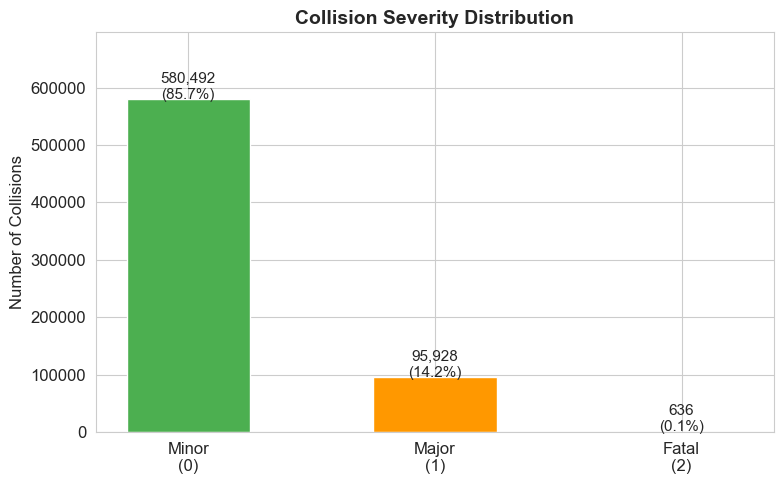

In [18]:
# 7.1 Severity Distribution
fig, ax = plt.subplots(figsize=(8,5))
counts = df['severity'].value_counts().sort_index()
bars = ax.bar([f"{severity_labels[i]}\n({i})" for i in counts.index],
              counts.values, color=['#4CAF50','#FF9800','#F44336'],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Collision Severity Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Collisions')
ax.set_ylim(0, counts.max()*1.2)
plt.tight_layout()
plt.savefig('plot_1_severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

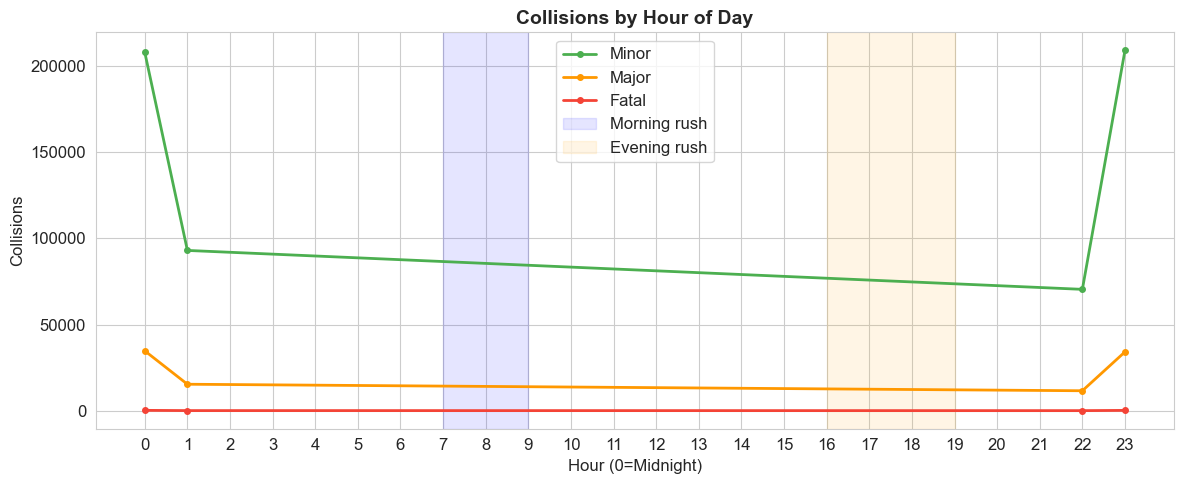

In [19]:
# 7.2 Collisions by Hour
fig, ax = plt.subplots(figsize=(12,5))
hourly = df.groupby(['OCC_HOUR','severity']).size().unstack(fill_value=0)
for i, col in enumerate(hourly.columns):
    ax.plot(hourly.index, hourly[col], marker='o', markersize=4,
            label=severity_labels[col], color=['#4CAF50','#FF9800','#F44336'][i], linewidth=2)
ax.axvspan(7,9,   alpha=0.1, color='blue',   label='Morning rush')
ax.axvspan(16,19, alpha=0.1, color='orange', label='Evening rush')
ax.set_title('Collisions by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (0=Midnight)')
ax.set_ylabel('Collisions')
ax.set_xticks(range(0,24))
ax.legend()
plt.tight_layout()
plt.savefig('plot_2_hourly_collisions.png', dpi=150, bbox_inches='tight')
plt.show()

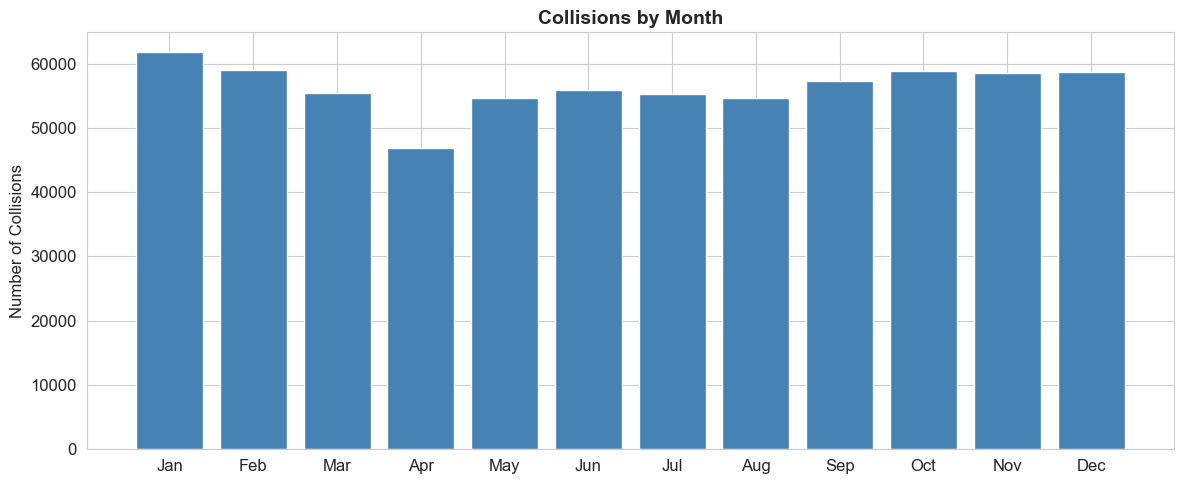

In [20]:
# 7.3 Collisions by Month
fig, ax = plt.subplots(figsize=(12,5))
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('OCC_MONTH').size().reindex(range(1,13), fill_value=0)
ax.bar(month_names, monthly.values, color='steelblue', edgecolor='white')
ax.set_title('Collisions by Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Collisions')
plt.tight_layout()
plt.savefig('plot_3_monthly_collisions.png', dpi=150, bbox_inches='tight')
plt.show()

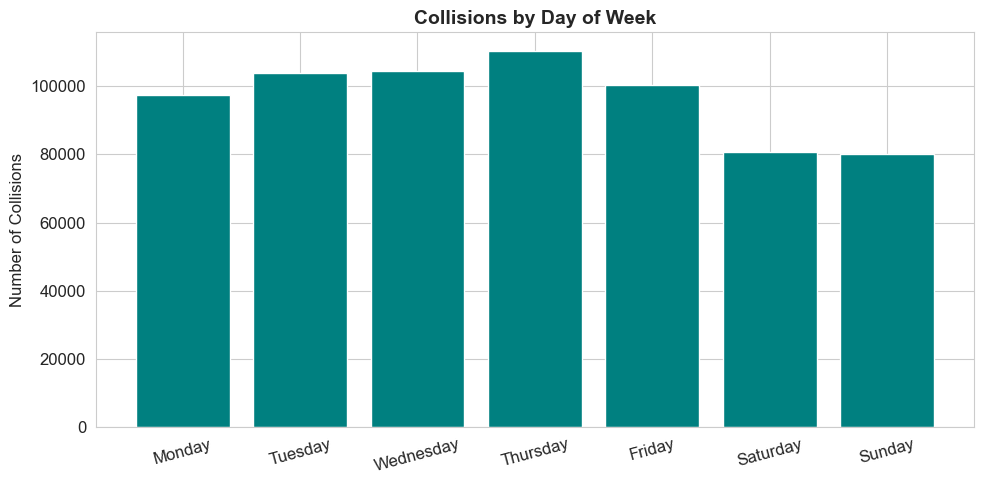

In [21]:
# 7.4 Collisions by Day of Week (reconstructed from one-hot)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_cols  = [c for c in df.columns if c.startswith('OCC_DOW_')]
dow_counts = pd.Series(
    {d.replace('OCC_DOW_',''):df[d].sum() for d in dow_cols}
).reindex(dow_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(dow_order, dow_counts.values, color='teal', edgecolor='white')
ax.set_title('Collisions by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Collisions')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot_4_dow_collisions.png', dpi=150, bbox_inches='tight')
plt.show()

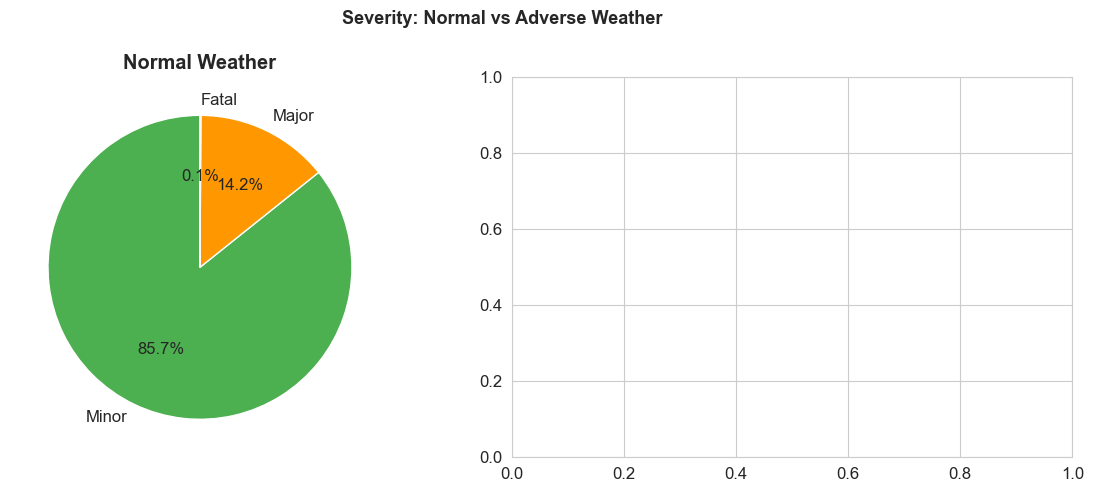

In [22]:
# 7.5 Weather vs Severity
if 'adverse_weather_w' in df.columns:
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    for i, (label, subset) in enumerate(df.groupby('adverse_weather_w')):
        c = subset['severity'].value_counts().sort_index()
        axes[i].pie(c.values, labels=[severity_labels[k] for k in c.index],
                    colors=['#4CAF50','#FF9800','#F44336'], autopct='%1.1f%%', startangle=90)
        axes[i].set_title('Adverse Weather' if label==1 else 'Normal Weather', fontweight='bold')
    plt.suptitle('Severity: Normal vs Adverse Weather', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_5_weather_severity.png', dpi=150, bbox_inches='tight')
    plt.show()

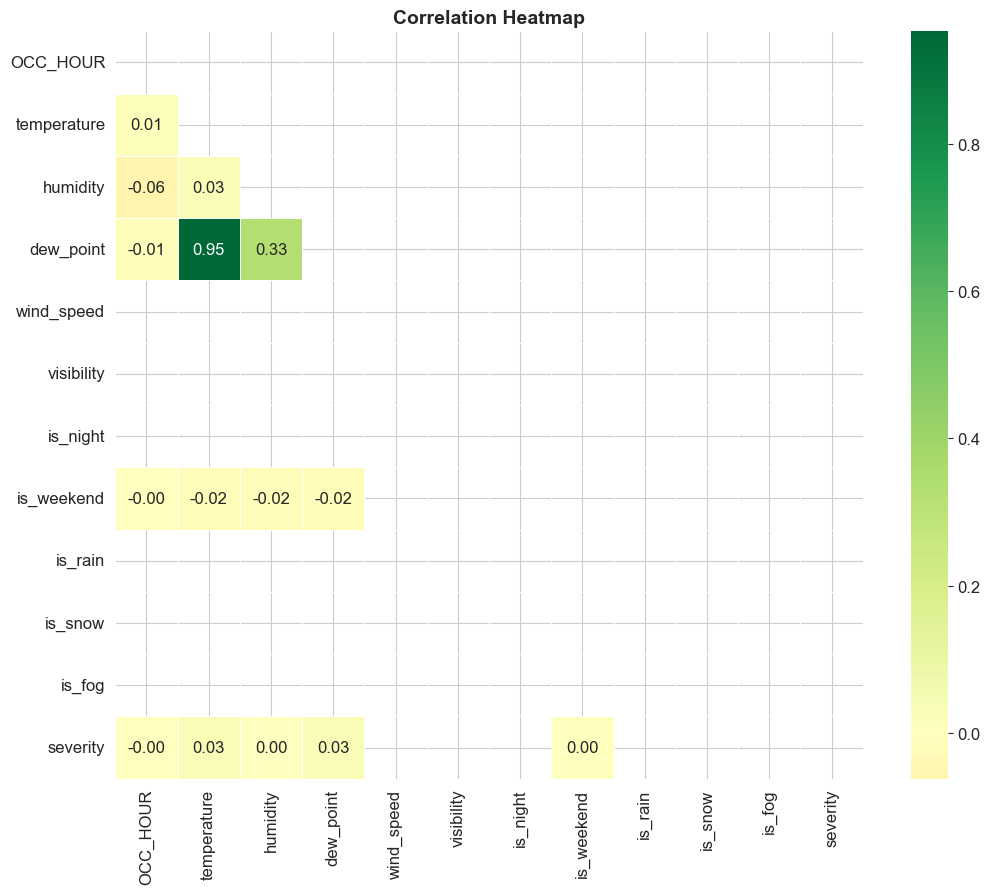

In [23]:
# 7.6 Correlation Heatmap
num_cols = ['OCC_HOUR','temperature','humidity','dew_point',
            'wind_speed','visibility','is_night','is_weekend',
            'is_rain','is_snow','is_fog','severity']
existing = [c for c in num_cols if c in df.columns]
fig, ax = plt.subplots(figsize=(11,9))
corr = df[existing].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

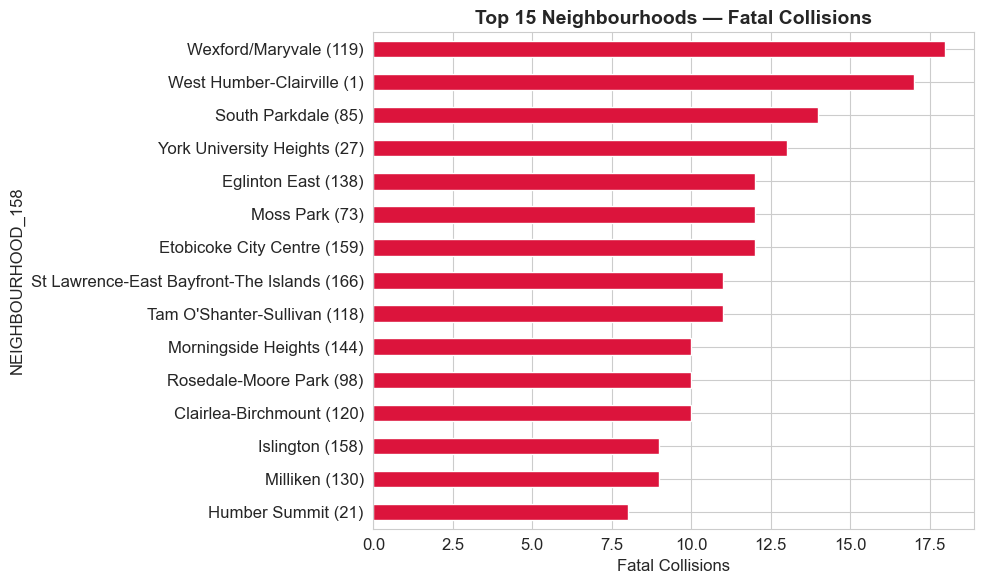

In [24]:
# 7.7 Top 15 Neighbourhoods by Fatal Collisions
if 'NEIGHBOURHOOD_158' in df.columns:
    fatal_hood = (df[df['severity']==2]
                  .groupby('NEIGHBOURHOOD_158').size()
                  .sort_values(ascending=False).head(15))
    fig, ax = plt.subplots(figsize=(10,6))
    fatal_hood.plot(kind='barh', color='crimson', ax=ax)
    ax.set_title('Top 15 Neighbourhoods — Fatal Collisions', fontsize=14, fontweight='bold')
    ax.set_xlabel('Fatal Collisions')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('plot_7_neighbourhood_fatal.png', dpi=150, bbox_inches='tight')
    plt.show()

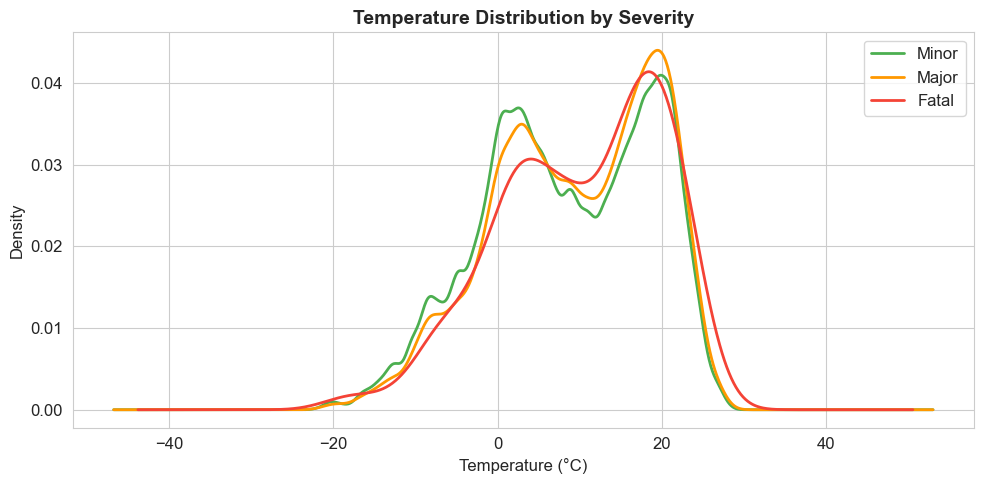

In [25]:
# 7.8 Temperature by Severity
if 'temperature' in df.columns:
    fig, ax = plt.subplots(figsize=(10,5))
    for sev, color in zip([0,1,2],['#4CAF50','#FF9800','#F44336']):
        df[df['severity']==sev]['temperature'].dropna().plot(
            kind='kde', ax=ax, color=color, label=severity_labels[sev], linewidth=2)
    ax.set_title('Temperature Distribution by Severity', fontsize=14, fontweight='bold')
    ax.set_xlabel('Temperature (\u00b0C)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plot_8_temperature_severity.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Section 8 — Prepare Data for Modeling

In [26]:
DROP_COLS = [
    'severity','OCC_DATE','datetime',
    'FATALITIES','INJURY_COLLISIONS','PD_COLLISIONS','FTR_COLLISIONS',
    'NEIGHBOURHOOD_158','DIVISION','weather_desc','geometry',
    '_id','OBJECTID','INDEX_','x','y'
]
drop_cols    = [c for c in DROP_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['severity'].copy()

# Convert object/bool to numeric
for col in X.select_dtypes(include=['object','bool']).columns:
    X[col] = pd.Categorical(X[col]).codes

X = X.fillna(X.median())

print(f'Features: {X.shape[1]} | Rows: {X.shape[0]:,}')
print(f'\nClass distribution:')
for k,v in y.value_counts().sort_index().items():
    print(f'  {severity_labels[k]}: {v:,} ({v/len(y)*100:.1f}%)')

Features: 40 | Rows: 677,056

Class distribution:
  Minor: 580,492 (85.7%)
  Major: 95,928 (14.2%)
  Fatal: 636 (0.1%)


In [27]:
# Train / Validation / Test split — 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train:      {len(X_train):,}')
print(f'Validation: {len(X_val):,}')
print(f'Test:       {len(X_test):,}')

Train:      473,939
Validation: 101,558
Test:       101,559


In [28]:
# SMOTE on training set ONLY
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('After SMOTE:')
for u, c in zip(*np.unique(y_train_sm, return_counts=True)):
    print(f'  {severity_labels[u]}: {c:,}')
print(f'Total: {len(X_train_sm):,}')

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

---
## Section 9 — Model Training (5 Models)

In [29]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_STATE, multi_class='ovr'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(128,64,32), max_iter=300,
        early_stopping=True, random_state=RANDOM_STATE)
}

trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    t = time.time()
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    print(f'Done ({time.time()-t:.1f}s)')

print('\nAll models trained!')

Training Logistic Regression... 

NameError: name 'X_train_sm' is not defined

---
## Section 10 — Model Evaluation & Comparison

In [ ]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    try:
        auc = roc_auc_score(y_test, model.predict_proba(X_test),
                            multi_class='ovr', average='weighted')
    except: auc = None
    results.append({
        'Model': name,
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':    round(f1_score(y_test, y_pred, average='macro'), 4),
        'ROC-AUC':     round(auc, 4) if auc else 'N/A'
    })

results_df = pd.DataFrame(results).sort_values('F1 Weighted', ascending=False)
print('Model Comparison (Test Set):')
results_df

In [ ]:
# Comparison bar chart
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(results_df))
w = 0.25
ax.bar(x-w, results_df['Accuracy'],    w, label='Accuracy',    color='steelblue')
ax.bar(x,   results_df['F1 Weighted'], w, label='F1 Weighted', color='darkorange')
ax.bar(x+w, results_df['F1 Macro'],   w, label='F1 Macro',    color='green')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0,1.1)
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Best model report
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
y_pred_best     = best_model.predict(X_test)

print(f'Best Model: {best_model_name}')
print('='*55)
print(classification_report(y_test, y_pred_best, target_names=['Minor','Major','Fatal']))

In [ ]:
# Confusion matrix — best model
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Minor','Major','Fatal']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# All 5 confusion matrices
fig, axes = plt.subplots(1,5, figsize=(22,4))
for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, model.predict(X_test)),
        display_labels=['Min','Maj','Fat']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10, fontweight='bold')
plt.suptitle('All Models — Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_11_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 11 — SHAP Explainability

In [ ]:
shap_model = trained_models['XGBoost']
sample_idx = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
X_shap     = X_test.iloc[sample_idx]

print('Computing SHAP values...')
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
print(f'Done! Shape: {np.array(shap_values).shape}')

In [ ]:
# Global importance
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  class_names=['Minor','Major','Fatal'], max_display=15, show=False)
plt.title('SHAP — Global Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_12_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Beeswarm — Fatal
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values[2], X_shap, max_display=15, show=False)
plt.title('SHAP Beeswarm — Fatal Predictions', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_13_shap_fatal_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Beeswarm — Major
plt.figure(figsize=(10,7))
shap.summary_plot(shap_values[1], X_shap, max_display=15, show=False)
plt.title('SHAP Beeswarm — Major Predictions', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_14_shap_major_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Waterfall — single fatal collision
fatal_indices = np.where(y_test.iloc[sample_idx].values == 2)[0]
if len(fatal_indices) > 0:
    idx = fatal_indices[0]
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[2][idx],
            base_values=explainer.expected_value[2],
            data=X_shap.iloc[idx].values,
            feature_names=X_shap.columns.tolist()
        ), max_display=12, show=False)
    plt.title('SHAP Waterfall — Single Fatal Collision', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_15_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No fatal in sample — increase sample size')

In [ ]:
# Top 10 fatal risk factors
shap_importance = pd.DataFrame({
    'Feature': X_shap.columns,
    'Mean |SHAP|': np.abs(shap_values[2]).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(10).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(shap_importance['Feature'][::-1], shap_importance['Mean |SHAP|'][::-1], color='crimson')
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Top 10 Risk Factors — Fatal Collisions', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_16_shap_top10_fatal.png', dpi=150, bbox_inches='tight')
plt.show()
print(shap_importance.to_string(index=False))

---
## Section 12 — Geospatial Hotspot Mapping

In [ ]:
# All collisions heatmap
coords_all = df[['LAT_WGS84','LONG_WGS84']].dropna().values.tolist()
m_all = folium.Map(location=[43.70,-79.42], zoom_start=11, tiles='CartoDB positron')
HeatMap(coords_all, radius=10, blur=15, max_zoom=13).add_to(m_all)
folium.LayerControl().add_to(m_all)
m_all.save('map_1_all_collisions_heatmap.html')
print(f'Saved map_1 ({len(coords_all):,} points)')
m_all

In [ ]:
# Fatal collisions map
fatal_df = df[df['severity']==2][['LAT_WGS84','LONG_WGS84']].dropna().copy()
m_fatal = folium.Map(location=[43.70,-79.42], zoom_start=11, tiles='CartoDB positron')
HeatMap(fatal_df.values.tolist(), radius=15, blur=20,
        gradient={0.2:'blue',0.5:'orange',1.0:'red'}).add_to(m_fatal)
for _, row in fatal_df.iterrows():
    folium.CircleMarker([row['LAT_WGS84'],row['LONG_WGS84']],
                        radius=4, color='red', fill=True, fill_opacity=0.7).add_to(m_fatal)
m_fatal.save('map_2_fatal_collisions.html')
print(f'Saved map_2 ({len(fatal_df):,} fatals)')
m_fatal

In [ ]:
# DBSCAN clustering
coords_rad = np.radians(fatal_df.values)
db = DBSCAN(eps=300/6371000, min_samples=3, metric='haversine').fit(coords_rad)
fatal_df['cluster'] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f'Hotspot zones found: {n_clusters}')
print(f'Noise points: {(db.labels_==-1).sum()}')
print(fatal_df[fatal_df['cluster']>=0]['cluster'].value_counts().head(10))

In [ ]:
# Map clusters
colors=['red','blue','green','purple','orange','darkred','darkblue',
        'darkgreen','cadetblue','darkpurple','pink','lightblue','lightgreen']
m_clust = folium.Map(location=[43.70,-79.42], zoom_start=11, tiles='CartoDB positron')
for _, row in fatal_df.iterrows():
    cid   = row['cluster']
    color = 'gray' if cid==-1 else colors[int(cid)%len(colors)]
    folium.CircleMarker([row['LAT_WGS84'],row['LONG_WGS84']],
                        radius=6, color=color, fill=True,
                        fill_opacity=0.8, popup=f'Cluster {cid}').add_to(m_clust)
m_clust.save('map_3_dbscan_clusters.html')
print('Saved map_3_dbscan_clusters.html')
m_clust

---
## Section 13 — Subgroup Analysis

In [ ]:
df_test = X_test.copy()
df_test['true_severity'] = y_test.values
df_test['pred_severity'] = best_model.predict(X_test)

In [ ]:
# By Season
season_cols = [c for c in df_test.columns if 'season_' in c]
if season_cols:
    df_test['season_label'] = df_test[season_cols].idxmax(axis=1).str.replace('season_','')
    rows = []
    for s, grp in df_test.groupby('season_label'):
        if len(grp) < 10: continue
        rows.append({'Season':s,
                     'F1':round(f1_score(grp['true_severity'],grp['pred_severity'],average='weighted'),4),
                     'Accuracy':round(accuracy_score(grp['true_severity'],grp['pred_severity']),4),
                     'N':len(grp)})
    print('Performance by Season:')
    print(pd.DataFrame(rows).to_string(index=False))

In [ ]:
# By Time of Day
hour_cols = [c for c in df_test.columns if 'hour_category_' in c]
if hour_cols:
    df_test['hour_label'] = df_test[hour_cols].idxmax(axis=1).str.replace('hour_category_','')
    rows = []
    for h, grp in df_test.groupby('hour_label'):
        if len(grp) < 10: continue
        rows.append({'Time':h,
                     'F1':round(f1_score(grp['true_severity'],grp['pred_severity'],average='weighted'),4),
                     'Accuracy':round(accuracy_score(grp['true_severity'],grp['pred_severity']),4),
                     'N':len(grp)})
    print('Performance by Time of Day:')
    print(pd.DataFrame(rows).to_string(index=False))

In [ ]:
# Fatal recall by time
print('Fatal Recall by Time (how many actual fatals were caught):')
if 'hour_label' in df_test.columns:
    for h, grp in df_test.groupby('hour_label'):
        fg = grp[grp['true_severity']==2]
        if len(fg)==0: continue
        recall = (fg['pred_severity']==2).sum() / len(fg)
        print(f'  {h:15s}: {recall*100:.1f}%  (n={len(fg)} fatals)')

---
## Section 14 — Final Summary

In [ ]:
print('='*65)
print('  TORONTO COLLISION SEVERITY — FINAL SUMMARY')
print('='*65)
print(f'\n DATASET')
print(f'  Records:    {len(df):,}')
print(f'  Features:   {X.shape[1]}')
print(f'  Date range: {df["datetime"].min().date()} to {df["datetime"].max().date()}')
print(f'\n CLASS DISTRIBUTION')
for k in [0,1,2]:
    n=(y==k).sum()
    print(f'  {severity_labels[k]:8s}: {n:,} ({n/len(y)*100:.1f}%)')
print(f'\n MODEL RESULTS')
print(results_df.to_string(index=False))
print(f'\n BEST MODEL: {best_model_name}')
print(f'\n TOP FATAL RISK FACTORS (SHAP):')
for i, row in shap_importance.iterrows():
    print(f'  {i+1:2d}. {row["Feature"]:35s} {row["Mean |SHAP|"]:.4f}')
print(f'\n FILES SAVED:')
for f in ['collisions_with_weather.csv',
          'plot_1 to plot_16 (.png)',
          'map_1_all_collisions_heatmap.html',
          'map_2_fatal_collisions.html',
          'map_3_dbscan_clusters.html']:
    print(f'  {f}')
print('='*65)